# Implementacao do Backpropagation em Python

**Autor:** Cleber de Jesus Salustiano  
**Matricula:** 20251mpca0170

## Descricao da Tarefa

Este notebook implementa e testa um `Multi Layer Perceptron (MLP)` em `NumPy`, com treinamento por **backpropagation**, e compara o resultado com o `MLPClassifier` do `scikit-learn`.

A implementacao aceita parametros para definir:

- a quantidade de camadas;
- a quantidade de neuronios em cada camada;
- a funcao de ativacao utilizada em cada camada.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from dataclasses import dataclass
from sklearn.datasets import load_iris, make_blobs
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

In [2]:
def make_logic_dataset(n=200, logic_fn=lambda a, b: bool(a) != bool(b), std=0.18, random_state=42):
    X, _ = make_blobs(
        n_samples=n,
        centers=[[0, 0], [1, 0], [1, 1], [0, 1]],
        cluster_std=std,
        random_state=random_state,
    )
    y = np.array([logic_fn(x1 > 0.5, x2 > 0.5) for x1, x2 in X], dtype=int)
    return X, y

def make_multiclass_dataset(n=400, n_classes=4, std=0.35, random_state=42, center_box=(-4.0, 4.0)):
    X, y = make_blobs(
        n_samples=n,
        centers=n_classes,
        n_features=2,
        cluster_std=std,
        center_box=center_box,
        random_state=random_state,
    )
    return X, y

def define_axes(X, offset=0.6):
    return [
        X[:, 0].min() - offset,
        X[:, 0].max() + offset,
        X[:, 1].min() - offset,
        X[:, 1].max() + offset,
    ]

def plot_dataset(ax, X, y, title):
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.Spectral, alpha=0.75, edgecolor='k', s=35)
    ax.set_title(title)
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    return scatter

def plot_boundary(ax, model, X, y, title):
    x_min, x_max, y_min, y_max = define_axes(X)
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 250),
        np.linspace(y_min, y_max, 250),
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    preds = model.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, preds, cmap=plt.cm.brg, alpha=0.20)
    plot_dataset(ax, X, y, title)

In [3]:
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def sigmoid_grad(x):
    s = sigmoid(x)
    return s * (1.0 - s)

def tanh(x):
    return np.tanh(x)

def tanh_grad(x):
    t = np.tanh(x)
    return 1.0 - t**2

def relu(x):
    return np.maximum(0.0, x)

def relu_grad(x):
    return (x > 0.0).astype(float)

def identity(x):
    return x

def identity_grad(x):
    return np.ones_like(x)

def softmax(x):
    shifted = x - np.max(x, axis=1, keepdims=True)
    exp_values = np.exp(shifted)
    return exp_values / np.sum(exp_values, axis=1, keepdims=True)

ACTIVATIONS = {
    'identity': (identity, identity_grad),
    'sigmoid': (sigmoid, sigmoid_grad),
    'tanh': (tanh, tanh_grad),
    'relu': (relu, relu_grad),
    'softmax': (softmax, None),
}

@dataclass
class EncodedTarget:
    values: np.ndarray
    classes: np.ndarray
    is_binary: bool

class BackpropMLPClassifier:
    def __init__(
        self,
        hidden_layer_sizes=(8,),
        hidden_activations='tanh',
        output_activation='auto',
        loss='auto',
        learning_rate=0.05,
        max_iter=4000,
        batch_size=None,
        shuffle=True,
        l2=0.0,
        tol=1e-6,
        n_iter_no_change=200,
        random_state=42,
        verbose=False,
    ):
        self.hidden_layer_sizes = tuple(hidden_layer_sizes)
        self.hidden_activations = hidden_activations
        self.output_activation = output_activation
        self.loss = loss
        self.learning_rate = learning_rate
        self.max_iter = max_iter
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.l2 = l2
        self.tol = tol
        self.n_iter_no_change = n_iter_no_change
        self.random_state = random_state
        self.verbose = verbose

    @staticmethod
    def _include_bias(X):
        return np.hstack((np.ones((X.shape[0], 1)), X))

    def _resolve_hidden_activations(self):
        n_hidden = len(self.hidden_layer_sizes)
        if isinstance(self.hidden_activations, str):
            activations = [self.hidden_activations] * n_hidden
        else:
            activations = list(self.hidden_activations)
        if len(activations) != n_hidden:
            raise ValueError('hidden_activations deve ter o mesmo tamanho de hidden_layer_sizes.')
        for activation_name in activations:
            if activation_name not in ACTIVATIONS:
                raise ValueError(f'Ativacao desconhecida: {activation_name}')
            if activation_name == 'softmax':
                raise ValueError('softmax deve ser usada apenas na camada de saida.')
        return activations

    def _encode_targets(self, y):
        y_array = np.asarray(y)
        classes = np.unique(y_array)
        class_to_index = {label: idx for idx, label in enumerate(classes)}
        indexed = np.vectorize(class_to_index.get)(y_array)
        if len(classes) == 2:
            values = indexed.reshape(-1, 1).astype(float)
            return EncodedTarget(values=values, classes=classes, is_binary=True)
        one_hot = np.zeros((len(y_array), len(classes)), dtype=float)
        one_hot[np.arange(len(y_array)), indexed] = 1.0
        return EncodedTarget(values=one_hot, classes=classes, is_binary=False)

    def _resolve_output_activation(self, encoded_target):
        if self.output_activation == 'auto':
            return 'sigmoid' if encoded_target.is_binary else 'softmax'
        if self.output_activation not in ACTIVATIONS:
            raise ValueError(f'Ativacao de saida desconhecida: {self.output_activation}')
        return self.output_activation

    def _resolve_loss(self, output_activation):
        if self.loss == 'auto':
            return 'cross_entropy' if output_activation in {'sigmoid', 'softmax'} else 'mse'
        if self.loss not in {'cross_entropy', 'mse'}:
            raise ValueError("loss deve ser 'auto', 'cross_entropy' ou 'mse'.")
        if self.loss == 'cross_entropy' and output_activation not in {'sigmoid', 'softmax'}:
            raise ValueError("cross_entropy requer ativacao de saida 'sigmoid' ou 'softmax'.")
        return self.loss

    def _weight_scale(self, fan_in, fan_out, activation_name):
        if activation_name == 'relu':
            return np.sqrt(2.0 / fan_in)
        return np.sqrt(2.0 / (fan_in + fan_out))

    def _initialize_weights(self, layer_sizes):
        rng = np.random.default_rng(self.random_state)
        weights = []
        for layer_index, (fan_in, fan_out) in enumerate(zip(layer_sizes[:-1], layer_sizes[1:])):
            activation_name = self.activation_names_[layer_index]
            scale = self._weight_scale(fan_in, fan_out, activation_name)
            layer_weights = rng.normal(loc=0.0, scale=scale, size=(fan_in + 1, fan_out))
            weights.append(layer_weights)
        return weights

    def _forward(self, X):
        self.activations_ = [X]
        self.biased_activations_ = []
        self.linear_outputs_ = []
        current = X
        for weights, activation_name in zip(self.weights_, self.activation_names_):
            current_with_bias = self._include_bias(current)
            linear_output = current_with_bias @ weights
            activation_fn, _ = ACTIVATIONS[activation_name]
            current = activation_fn(linear_output)
            self.biased_activations_.append(current_with_bias)
            self.linear_outputs_.append(linear_output)
            self.activations_.append(current)
        return current

    def _compute_loss(self, y_true, y_pred):
        eps = 1e-12
        if self.loss_name_ == 'cross_entropy':
            if self.output_activation_name_ == 'sigmoid':
                clipped = np.clip(y_pred, eps, 1.0 - eps)
                data_loss = -np.mean(y_true * np.log(clipped) + (1.0 - y_true) * np.log(1.0 - clipped))
            else:
                clipped = np.clip(y_pred, eps, 1.0)
                data_loss = -np.mean(np.sum(y_true * np.log(clipped), axis=1))
        else:
            data_loss = 0.5 * np.mean((y_true - y_pred) ** 2)
        if self.l2 <= 0.0:
            return float(data_loss)
        penalty = sum(np.sum(weight[1:, :] ** 2) for weight in self.weights_)
        penalty *= self.l2 / (2.0 * len(y_true))
        return float(data_loss + penalty)

    def _backward(self, y_true, y_pred):
        sample_count = len(y_true)
        gradients = [np.zeros_like(weight) for weight in self.weights_]
        if self.loss_name_ == 'cross_entropy' and self.output_activation_name_ in {'sigmoid', 'softmax'}:
            delta = y_pred - y_true
        else:
            _, output_grad_fn = ACTIVATIONS[self.output_activation_name_]
            delta = (y_pred - y_true) * output_grad_fn(self.linear_outputs_[-1])
        for layer_index in range(len(self.weights_) - 1, -1, -1):
            gradient = self.biased_activations_[layer_index].T @ delta / sample_count
            if self.l2 > 0.0:
                regularization = np.vstack((np.zeros((1, self.weights_[layer_index].shape[1])), self.weights_[layer_index][1:, :]))
                gradient += (self.l2 / sample_count) * regularization
            gradients[layer_index] = gradient
            if layer_index == 0:
                continue
            weights_without_bias = self.weights_[layer_index][1:, :]
            _, hidden_grad_fn = ACTIVATIONS[self.activation_names_[layer_index - 1]]
            delta = (delta @ weights_without_bias.T) * hidden_grad_fn(self.linear_outputs_[layer_index - 1])
        return gradients

    def _update_weights(self, gradients):
        for index, gradient in enumerate(gradients):
            self.weights_[index] -= self.learning_rate * gradient

    def _iterate_batches(self, X, y):
        sample_count = len(X)
        batch_size = self.batch_size or sample_count
        batch_size = max(1, min(batch_size, sample_count))
        indices = np.arange(sample_count)
        if self.shuffle:
            self._rng.shuffle(indices)
        X_shuffled = X[indices]
        y_shuffled = y[indices]
        for start in range(0, sample_count, batch_size):
            stop = start + batch_size
            yield X_shuffled[start:stop], y_shuffled[start:stop]

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        encoded_target = self._encode_targets(y)
        y_encoded = encoded_target.values
        self.classes_ = encoded_target.classes
        self.output_dim_ = y_encoded.shape[1]
        self.hidden_activation_names_ = self._resolve_hidden_activations()
        self.output_activation_name_ = self._resolve_output_activation(encoded_target)
        self.loss_name_ = self._resolve_loss(self.output_activation_name_)
        self.activation_names_ = self.hidden_activation_names_ + [self.output_activation_name_]
        layer_sizes = [X.shape[1], *self.hidden_layer_sizes, self.output_dim_]
        self.weights_ = self._initialize_weights(layer_sizes)
        self.loss_history_ = []
        self._rng = np.random.default_rng(self.random_state)
        best_weights = [weight.copy() for weight in self.weights_]
        best_loss = np.inf
        epochs_without_improvement = 0
        for epoch in range(self.max_iter):
            for batch_X, batch_y in self._iterate_batches(X, y_encoded):
                batch_predictions = self._forward(batch_X)
                gradients = self._backward(batch_y, batch_predictions)
                self._update_weights(gradients)
            full_predictions = self._forward(X)
            loss_value = self._compute_loss(y_encoded, full_predictions)
            self.loss_history_.append(loss_value)
            if self.verbose and (epoch == 0 or (epoch + 1) % 100 == 0):
                print(f'epoca={epoch + 1} loss={loss_value:.6f}')
            if best_loss - loss_value > self.tol:
                best_loss = loss_value
                best_weights = [weight.copy() for weight in self.weights_]
                epochs_without_improvement = 0
            else:
                epochs_without_improvement += 1
            if epochs_without_improvement >= self.n_iter_no_change:
                break
        self.weights_ = best_weights
        self.best_loss_ = best_loss
        self.n_iter_ = len(self.loss_history_)
        return self

    def decision_function(self, X):
        X = np.asarray(X, dtype=float)
        return self._forward(X)

    def predict_proba(self, X):
        probabilities = self.decision_function(X)
        if probabilities.shape[1] == 1:
            return np.hstack((1.0 - probabilities, probabilities))
        return probabilities

    def predict(self, X):
        probabilities = self.predict_proba(X)
        predicted_indices = np.argmax(probabilities, axis=1)
        return self.classes_[predicted_indices]

    def score(self, X, y):
        y_array = np.asarray(y)
        predictions = self.predict(X)
        return float(np.mean(predictions == y_array))

## 1. Teste Inicial com Problema Nao Linear

O primeiro experimento usa o problema XOR para mostrar que um modelo linear nao consegue resolver bem uma tarefa nao linearmente separavel, enquanto o MLP com backpropagation consegue aprender uma representacao intermediaria adequada.

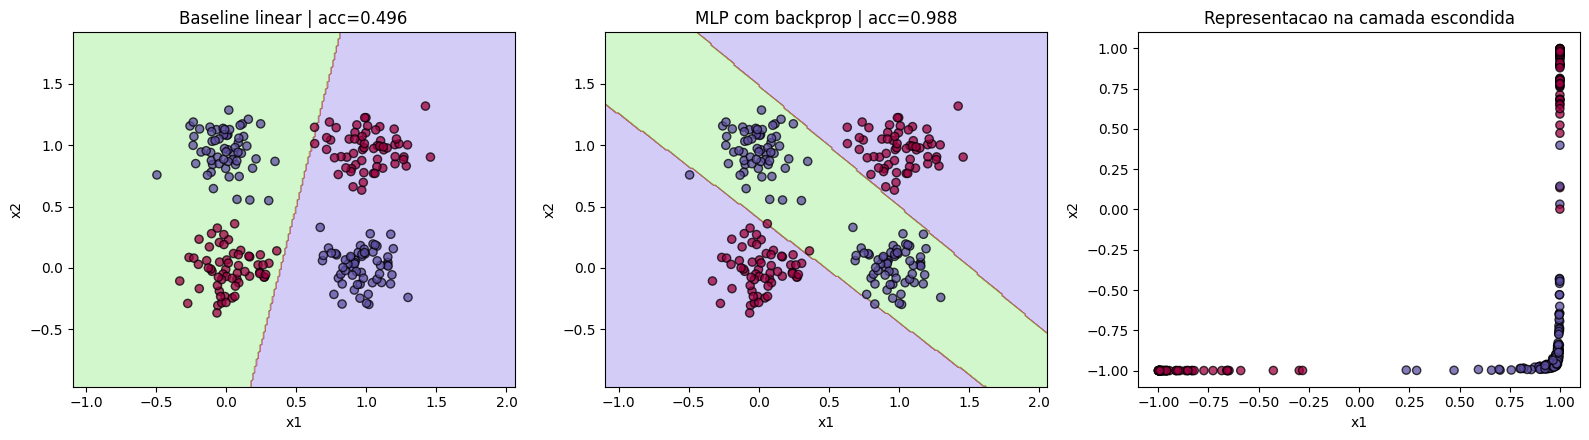

Acuracia baseline linear no XOR: 0.4958
Acuracia do MLP com backprop no XOR: 0.9875
Epocas executadas: 5000


In [4]:
X_xor, y_xor = make_logic_dataset(n=240, logic_fn=lambda a, b: bool(a) != bool(b), std=0.16, random_state=7)

linear_baseline = LogisticRegression(max_iter=2000, random_state=42)
linear_baseline.fit(X_xor, y_xor)

xor_mlp = BackpropMLPClassifier(
    hidden_layer_sizes=(2,),
    hidden_activations='tanh',
    output_activation='sigmoid',
    learning_rate=0.08,
    max_iter=5000,
    batch_size=32,
    l2=1e-4,
    tol=0.0,
    n_iter_no_change=400,
    random_state=7,
)
xor_mlp.fit(X_xor, y_xor)

linear_acc = accuracy_score(y_xor, linear_baseline.predict(X_xor))
mlp_acc = accuracy_score(y_xor, xor_mlp.predict(X_xor))
xor_mlp.predict(X_xor)
hidden_space = xor_mlp.activations_[1]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
plot_boundary(axes[0], linear_baseline, X_xor, y_xor, f'Baseline linear | acc={linear_acc:.3f}')
plot_boundary(axes[1], xor_mlp, X_xor, y_xor, f'MLP com backprop | acc={mlp_acc:.3f}')
plot_dataset(axes[2], hidden_space, y_xor, 'Representacao na camada escondida')
plt.tight_layout()
plt.show()

print(f'Acuracia baseline linear no XOR: {linear_acc:.4f}')
print(f'Acuracia do MLP com backprop no XOR: {mlp_acc:.4f}')
print(f'Epocas executadas: {xor_mlp.n_iter_}')

In [5]:
logic_problems = {
    'OR': lambda a, b: bool(a) or bool(b),
    'AND': lambda a, b: bool(a) and bool(b),
    'XOR': lambda a, b: bool(a) != bool(b),
}

for name, logic_fn in logic_problems.items():
    X_logic, y_logic = make_logic_dataset(n=220, logic_fn=logic_fn, std=0.16, random_state=11)
    model = BackpropMLPClassifier(
        hidden_layer_sizes=(6, 4),
        hidden_activations=('tanh', 'tanh'),
        learning_rate=0.05,
        max_iter=2500,
        batch_size=32,
        l2=1e-4,
        random_state=11,
    )
    model.fit(X_logic, y_logic)
    acc = accuracy_score(y_logic, model.predict(X_logic))
    print(f'{name}: acuracia={acc:.4f} | epocas={model.n_iter_} | loss_final={model.loss_history_[-1]:.6f}')

OR: acuracia=1.0000 | epocas=2500 | loss_final=0.000793


AND: acuracia=1.0000 | epocas=2500 | loss_final=0.000594


XOR: acuracia=1.0000 | epocas=2500 | loss_final=0.001022


## 2. Teste com Problema Multiclasse

Neste experimento, o MLP e avaliado em um conjunto sintético multiclasse. Para isso, a camada de saida usa `softmax` e a funcao de custo usa `cross-entropy`, mantendo a retropropagacao do erro entre todas as camadas.

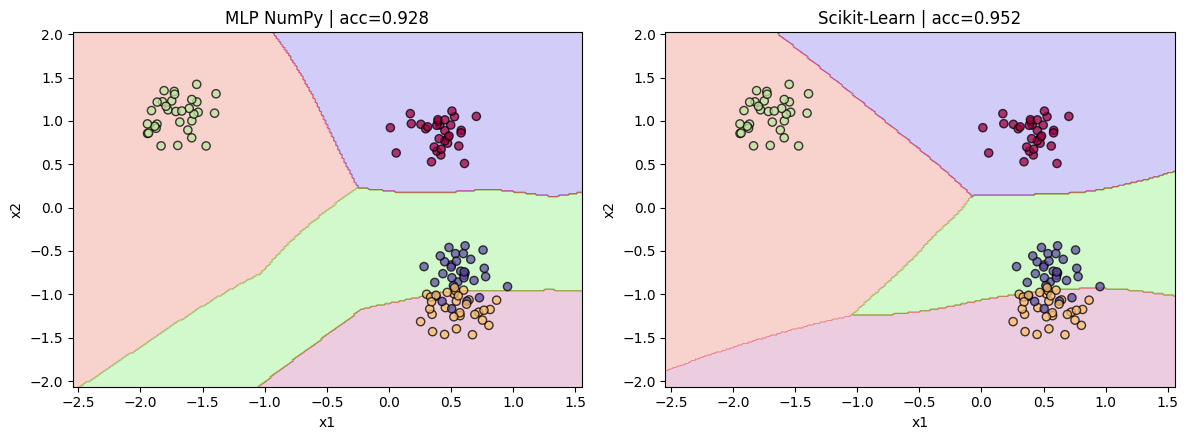

Acuracia multiclasse do MLP em NumPy: 0.9280
Acuracia multiclasse do Scikit-Learn: 0.9520


In [6]:
X_multi, y_multi = make_multiclass_dataset(n=500, n_classes=4, std=0.35, random_state=24)
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    X_multi,
    y_multi,
    test_size=0.25,
    random_state=24,
    stratify=y_multi,
)

scaler_multi = StandardScaler()
X_train_multi = scaler_multi.fit_transform(X_train_multi)
X_test_multi = scaler_multi.transform(X_test_multi)

custom_multi = BackpropMLPClassifier(
    hidden_layer_sizes=(18, 10),
    hidden_activations=('tanh', 'relu'),
    output_activation='softmax',
    learning_rate=0.03,
    max_iter=4500,
    batch_size=32,
    l2=1e-4,
    random_state=24,
)

sklearn_multi = MLPClassifier(
    hidden_layer_sizes=(18, 10),
    activation='tanh',
    learning_rate_init=0.03,
    max_iter=4500,
    random_state=24,
)

custom_multi.fit(X_train_multi, y_train_multi)
sklearn_multi.fit(X_train_multi, y_train_multi)

custom_multi_acc = accuracy_score(y_test_multi, custom_multi.predict(X_test_multi))
sklearn_multi_acc = accuracy_score(y_test_multi, sklearn_multi.predict(X_test_multi))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
plot_boundary(axes[0], custom_multi, X_test_multi, y_test_multi, f'MLP NumPy | acc={custom_multi_acc:.3f}')
plot_boundary(axes[1], sklearn_multi, X_test_multi, y_test_multi, f'Scikit-Learn | acc={sklearn_multi_acc:.3f}')
plt.tight_layout()
plt.show()

print(f'Acuracia multiclasse do MLP em NumPy: {custom_multi_acc:.4f}')
print(f'Acuracia multiclasse do Scikit-Learn: {sklearn_multi_acc:.4f}')

## 3. Comparacao com o Scikit-Learn

Por fim, o modelo implementado em `NumPy` e comparado com o `MLPClassifier` do `scikit-learn` no conjunto de dados Iris.

In [7]:
iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(
    iris.data,
    iris.target,
    test_size=0.25,
    random_state=42,
    stratify=iris.target,
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

custom_iris = BackpropMLPClassifier(
    hidden_layer_sizes=(12, 8),
    hidden_activations=('tanh', 'tanh'),
    output_activation='softmax',
    learning_rate=0.03,
    max_iter=5000,
    batch_size=16,
    l2=1e-4,
    random_state=42,
)

sklearn_iris = MLPClassifier(
    hidden_layer_sizes=(12, 8),
    activation='tanh',
    learning_rate_init=0.03,
    max_iter=5000,
    random_state=42,
)

custom_iris.fit(X_train, y_train)
sklearn_iris.fit(X_train, y_train)

custom_predictions = custom_iris.predict(X_test)
sklearn_predictions = sklearn_iris.predict(X_test)

custom_accuracy = accuracy_score(y_test, custom_predictions)
sklearn_accuracy = accuracy_score(y_test, sklearn_predictions)

print(f'Acuracia MLP NumPy no Iris: {custom_accuracy:.4f}')
print(f'Acuracia MLP Scikit-Learn no Iris: {sklearn_accuracy:.4f}')
print()
print('Relatorio do modelo em NumPy')
print(classification_report(y_test, custom_predictions, target_names=iris.target_names))
print('Relatorio do modelo do Scikit-Learn')
print(classification_report(y_test, sklearn_predictions, target_names=iris.target_names))

Acuracia MLP NumPy no Iris: 0.9474
Acuracia MLP Scikit-Learn no Iris: 0.9474

Relatorio do modelo em NumPy
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       0.92      0.92      0.92        13
   virginica       0.92      0.92      0.92        13

    accuracy                           0.95        38
   macro avg       0.95      0.95      0.95        38
weighted avg       0.95      0.95      0.95        38

Relatorio do modelo do Scikit-Learn
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       0.92      0.92      0.92        13
   virginica       0.92      0.92      0.92        13

    accuracy                           0.95        38
   macro avg       0.95      0.95      0.95        38
weighted avg       0.95      0.95      0.95        38



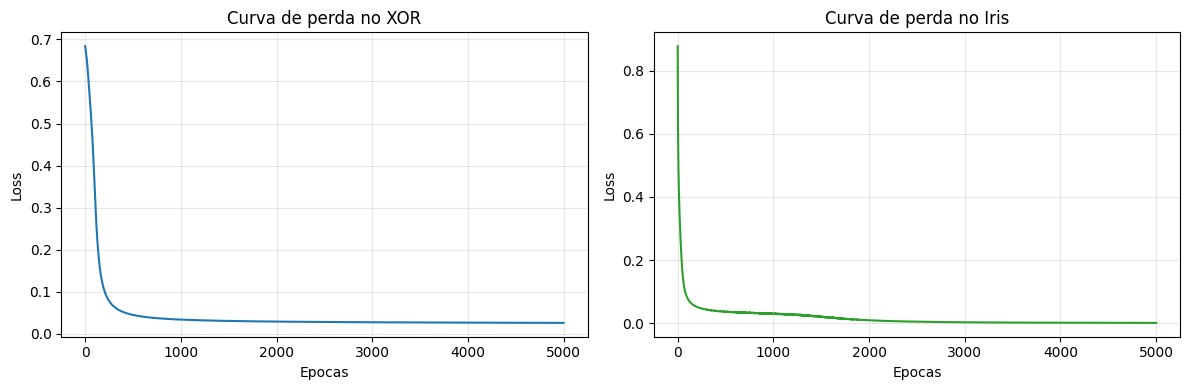

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(xor_mlp.loss_history_, color='tab:blue')
axes[0].set_title('Curva de perda no XOR')
axes[0].set_xlabel('Epocas')
axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)

axes[1].plot(custom_iris.loss_history_, color='tab:green')
axes[1].set_title('Curva de perda no Iris')
axes[1].set_xlabel('Epocas')
axes[1].set_ylabel('Loss')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()